<a href="https://colab.research.google.com/github/lightcode01-oss/IYB_INTERNSHIP/blob/main/Day_03_Dataset_Understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DAY 03 — Dataset Understanding & Feature Analysis

## YBI Foundation — Python, AI & Data Science Internship

### Objective

The objective of Day 03 is to understand the structure, data types,
features and statistical characteristics of the selected Student Performance
dataset.

Before applying machine learning algorithms, it is important to understand
the data properly. This helps in deciding which variables require encoding,
scaling, transformation or other preprocessing techniques.

### Today's Work

- Load the selected dataset.
- Inspect its dimensions.
- Examine all features.
- Identify numerical and categorical variables.
- Study statistical characteristics.
- Inspect unique values.
- Analyze important academic variables.
- Study selected student characteristics.
- Investigate relationships between selected features and performance.
- Create a feature summary for future preprocessing.

No machine learning model will be trained today.

In [1]:
# DAY 03
# Installing and importing required libraries

!pip -q install ucimlrepo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Load the UCI Student Performance dataset

student_performance = fetch_ucirepo(id=320)

X = student_performance.data.features
y = student_performance.data.targets

print("Dataset loaded successfully.")
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Dataset loaded successfully.
Features shape: (649, 30)
Target shape: (649, 3)


In [3]:
# Create the working DataFrame

df = X.copy()

df["G3"] = y["G3"]

print("Working DataFrame created.")
print("Shape:", df.shape)

df.head()

Working DataFrame created.
Shape: (649, 31)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,no,4,3,4,1,1,3,4,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,no,5,3,3,1,1,3,2,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,no,4,3,2,2,3,3,6,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,3,2,2,1,1,5,0,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,no,no,4,3,2,1,2,5,0,13


In [4]:
# Convert final grade into project-defined performance categories

def performance_category(grade):
    if grade < 10:
        return "Low"
    elif grade < 15:
        return "Medium"
    else:
        return "High"


df["performance_category"] = df["G3"].apply(performance_category)

print(df["performance_category"].value_counts())

performance_category
Medium    418
High      131
Low       100
Name: count, dtype: int64


In [5]:
# Inspect dataset dimensions

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 649
Number of columns: 32


In [6]:
# Display all column names

print("Dataset Features:\n")

for number, column in enumerate(df.columns, start=1):
    print(f"{number}. {column}")

Dataset Features:

1. school
2. sex
3. age
4. address
5. famsize
6. Pstatus
7. Medu
8. Fedu
9. Mjob
10. Fjob
11. reason
12. guardian
13. traveltime
14. studytime
15. failures
16. schoolsup
17. famsup
18. paid
19. activities
20. nursery
21. higher
22. internet
23. romantic
24. famrel
25. freetime
26. goout
27. Dalc
28. Walc
29. health
30. absences
31. G3
32. performance_category


In [7]:
# Check data types of all columns

print(df.dtypes)

school                  object
sex                     object
age                      int64
address                 object
famsize                 object
Pstatus                 object
Medu                     int64
Fedu                     int64
Mjob                    object
Fjob                    object
reason                  object
guardian                object
traveltime               int64
studytime                int64
failures                 int64
schoolsup               object
famsup                  object
paid                    object
activities              object
nursery                 object
higher                  object
internet                object
romantic                object
famrel                   int64
freetime                 int64
goout                    int64
Dalc                     int64
Walc                     int64
health                   int64
absences                 int64
G3                       int64
performance_category    object
dtype: o

In [8]:
# Count columns by data type

print("Data type summary:")
print(df.dtypes.value_counts())

Data type summary:
object    18
int64     14
Name: count, dtype: int64


In [9]:
# Detailed DataFrame information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 32 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   school                649 non-null    object
 1   sex                   649 non-null    object
 2   age                   649 non-null    int64 
 3   address               649 non-null    object
 4   famsize               649 non-null    object
 5   Pstatus               649 non-null    object
 6   Medu                  649 non-null    int64 
 7   Fedu                  649 non-null    int64 
 8   Mjob                  649 non-null    object
 9   Fjob                  649 non-null    object
 10  reason                649 non-null    object
 11  guardian              649 non-null    object
 12  traveltime            649 non-null    int64 
 13  studytime             649 non-null    int64 
 14  failures              649 non-null    int64 
 15  schoolsup             649 non-null    ob

In [10]:
# Identify numerical and categorical columns

numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = df.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G3']

Categorical Columns:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'performance_category']


In [11]:
print("Number of numerical columns:", len(numerical_columns))
print("Number of categorical columns:", len(categorical_columns))

Number of numerical columns: 14
Number of categorical columns: 18


In [12]:
# Statistical summary of numerical variables

df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
age,649.0,16.744222,1.218138,15.0,16.0,17.0,18.0,22.0
Medu,649.0,2.514638,1.134552,0.0,2.0,2.0,4.0,4.0
Fedu,649.0,2.306626,1.099931,0.0,1.0,2.0,3.0,4.0
traveltime,649.0,1.568567,0.748660,1.0,1.0,1.0,2.0,4.0
studytime,649.0,1.930663,0.829510,1.0,1.0,2.0,2.0,4.0
failures,649.0,0.221880,0.593235,0.0,0.0,0.0,0.0,3.0
famrel,649.0,3.930663,0.955717,1.0,4.0,4.0,5.0,5.0
freetime,649.0,3.180277,1.051093,1.0,3.0,3.0,4.0,5.0
goout,649.0,3.184900,1.175766,1.0,2.0,3.0,4.0,5.0
Dalc,649.0,1.502311,0.924834,1.0,1.0,1.0,2.0,5.0


In [13]:
# Number of unique values in each feature

unique_counts = df.nunique().sort_values()

unique_counts

,0
school,2
sex,2
address,2
famsize,2
Pstatus,2
schoolsup,2
paid,2
famsup,2
nursery,2
romantic,2


In [14]:
# Display unique values of categorical variables

for column in categorical_columns:
    print("\n" + "=" * 50)
    print("Column:", column)
    print("Unique values:", df[column].unique())


Column: school
Unique values: ['GP' 'MS']

Column: sex
Unique values: ['F' 'M']

Column: address
Unique values: ['U' 'R']

Column: famsize
Unique values: ['GT3' 'LE3']

Column: Pstatus
Unique values: ['A' 'T']

Column: Mjob
Unique values: ['at_home' 'health' 'other' 'services' 'teacher']

Column: Fjob
Unique values: ['teacher' 'other' 'services' 'health' 'at_home']

Column: reason
Unique values: ['course' 'other' 'home' 'reputation']

Column: guardian
Unique values: ['mother' 'father' 'other']

Column: schoolsup
Unique values: ['yes' 'no']

Column: famsup
Unique values: ['no' 'yes']

Column: paid
Unique values: ['no' 'yes']

Column: activities
Unique values: ['no' 'yes']

Column: nursery
Unique values: ['yes' 'no']

Column: higher
Unique values: ['yes' 'no']

Column: internet
Unique values: ['no' 'yes']

Column: romantic
Unique values: ['no' 'yes']

Column: performance_category
Unique values: ['Medium' 'High' 'Low']


In [16]:
print(df.columns.tolist())

['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G3', 'performance_category']


In [17]:
print(df.head())

  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  romantic famrel  freetime  goout  Dalc Walc health absences  G3  \
0       no      4         3      4     1    1      3        4  11   
1       no      5         3      3     1    1      3        2  11   
2       no      4         3      2     2    3      3        6  12   
3      yes      3         2      2     1    1      5        0  14   
4       no      4         3      2     1    2      5        0  13   

  performance_category  
0               Medium  
1               Medium  
2               Medium 

In [18]:
# Analyze available grade information

grade_columns = ["G3"]

for column in grade_columns:
    print("\n" + "=" * 50)
    print(column)
    print("Minimum:", df[column].min())
    print("Maximum:", df[column].max())
    print("Mean:", round(df[column].mean(), 2))
    print("Median:", df[column].median())


G3
Minimum: 0
Maximum: 19
Mean: 11.91
Median: 12.0


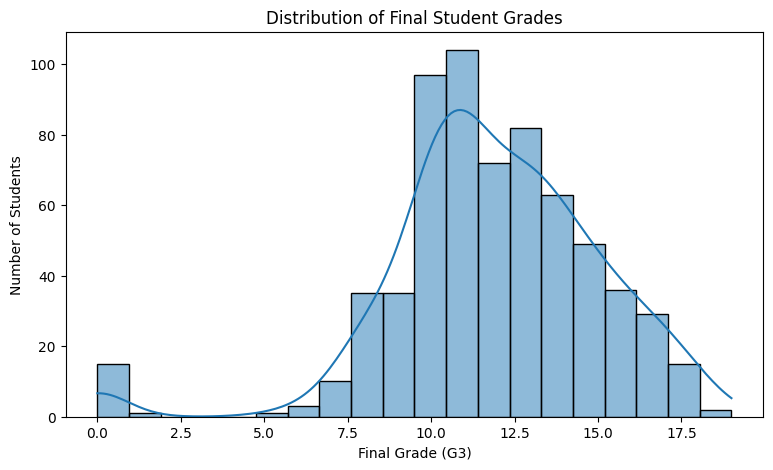

In [19]:
# Final Grade Distribution

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="G3",
    bins=20,
    kde=True
)

plt.title("Distribution of Final Student Grades")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")
plt.show()

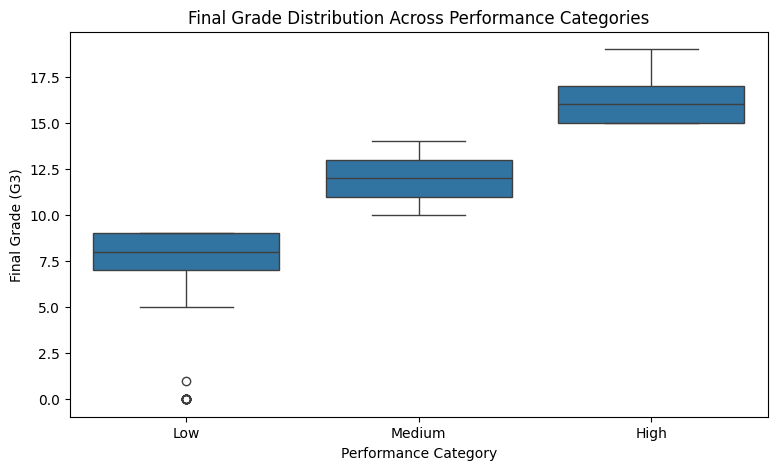

In [20]:
# Final Grade by Performance Category

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="performance_category",
    y="G3",
    order=["Low", "Medium", "High"]
)

plt.title("Final Grade Distribution Across Performance Categories")
plt.xlabel("Performance Category")
plt.ylabel("Final Grade (G3)")
plt.show()

In [21]:
# Study time distribution

print(df["studytime"].value_counts().sort_index())

studytime
1    212
2    305
3     97
4     35
Name: count, dtype: int64


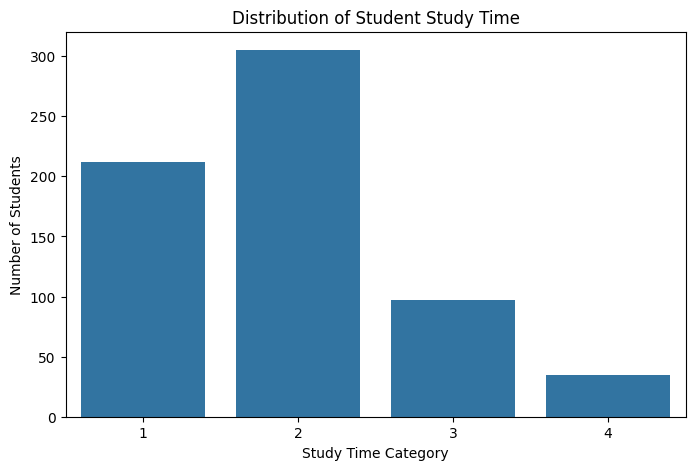

In [22]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="studytime"
)

plt.title("Distribution of Student Study Time")
plt.xlabel("Study Time Category")
plt.ylabel("Number of Students")

plt.show()

In [23]:
# Previous failures distribution

print(df["failures"].value_counts().sort_index())

failures
0    549
1     70
2     16
3     14
Name: count, dtype: int64


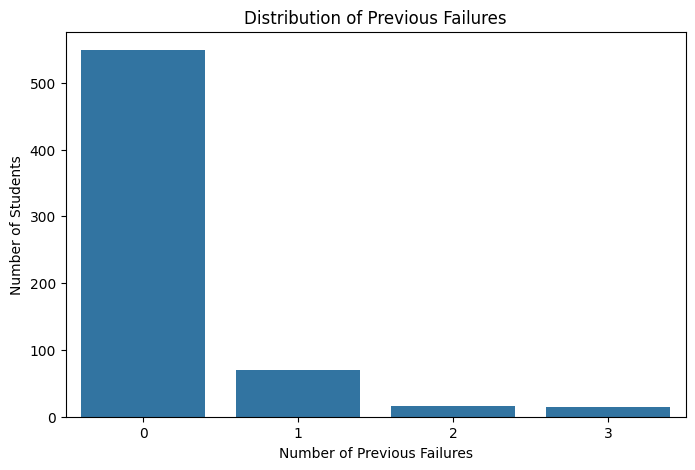

In [24]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="failures"
)

plt.title("Distribution of Previous Failures")
plt.xlabel("Number of Previous Failures")
plt.ylabel("Number of Students")

plt.show()

In [25]:
# Analyze student absences

print("Minimum absences:", df["absences"].min())
print("Maximum absences:", df["absences"].max())
print("Average absences:", round(df["absences"].mean(), 2))
print("Median absences:", df["absences"].median())

Minimum absences: 0
Maximum absences: 32
Average absences: 3.66
Median absences: 2.0


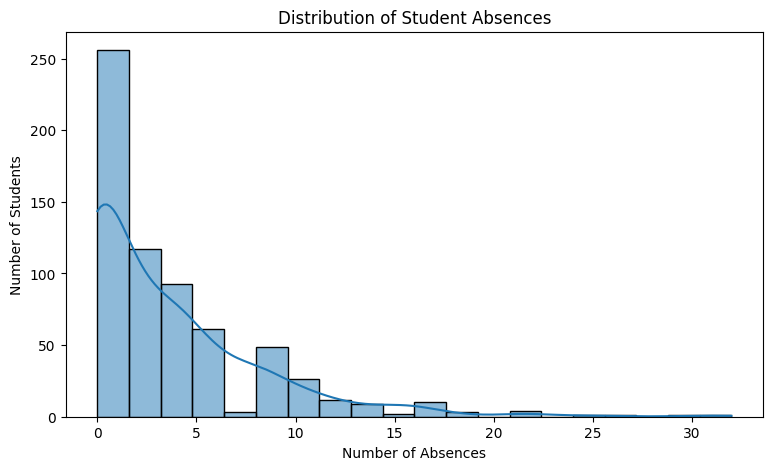

In [26]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="absences",
    bins=20,
    kde=True
)

plt.title("Distribution of Student Absences")
plt.xlabel("Number of Absences")
plt.ylabel("Number of Students")

plt.show()

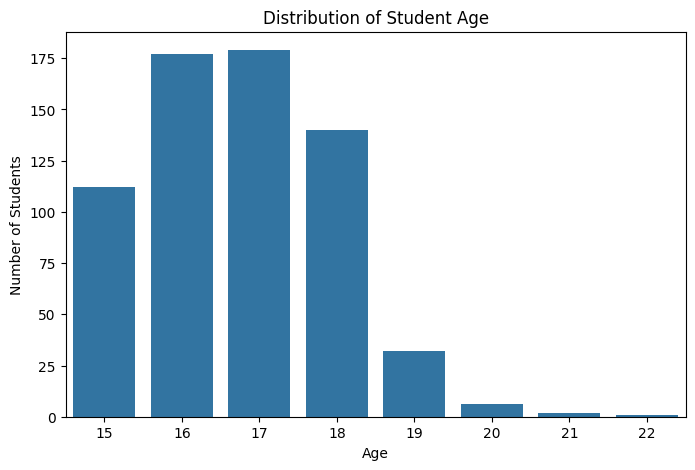

In [27]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="age"
)

plt.title("Distribution of Student Age")
plt.xlabel("Age")
plt.ylabel("Number of Students")

plt.show()

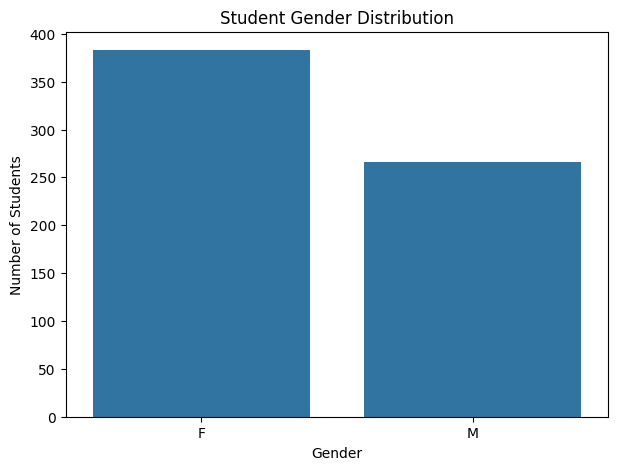

In [28]:
# Analyze student gender distribution

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="sex")

plt.title("Student Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Students")

plt.show()

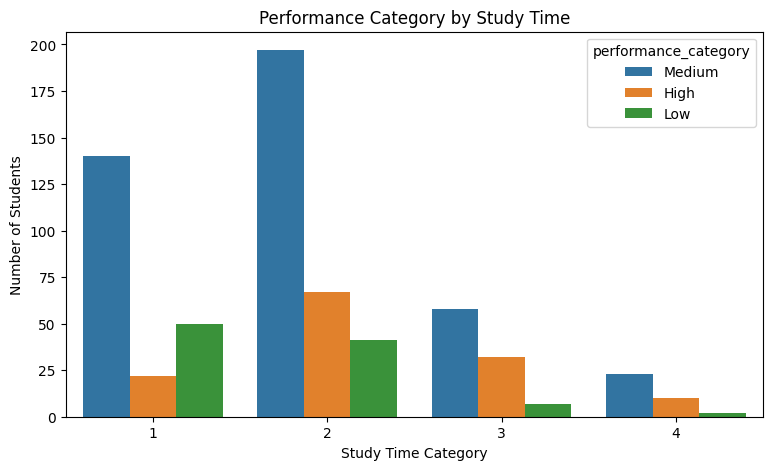

In [29]:
# Analyze performance category by study time

plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="studytime",
    hue="performance_category"
)

plt.title("Performance Category by Study Time")
plt.xlabel("Study Time Category")
plt.ylabel("Number of Students")

plt.show()

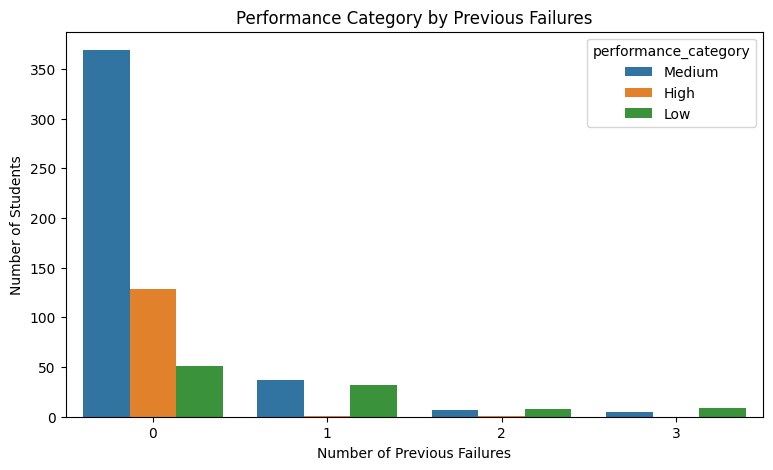

In [30]:
# Analyze performance category by previous failures

plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="failures",
    hue="performance_category"
)

plt.title("Performance Category by Previous Failures")
plt.xlabel("Number of Previous Failures")
plt.ylabel("Number of Students")

plt.show()

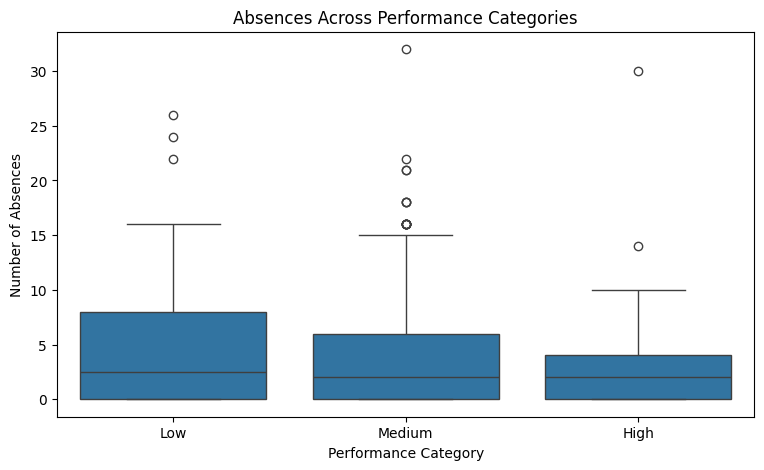

In [31]:
# Analyze absences across performance categories

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="performance_category",
    y="absences",
    order=["Low", "Medium", "High"]
)

plt.title("Absences Across Performance Categories")
plt.xlabel("Performance Category")
plt.ylabel("Number of Absences")

plt.show()

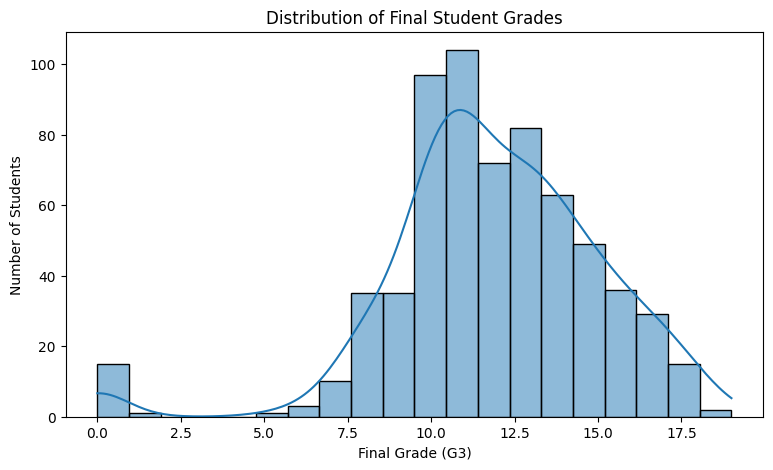

In [32]:
# Analyze final grade distribution

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="G3",
    bins=20,
    kde=True
)

plt.title("Distribution of Final Student Grades")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")

plt.show()

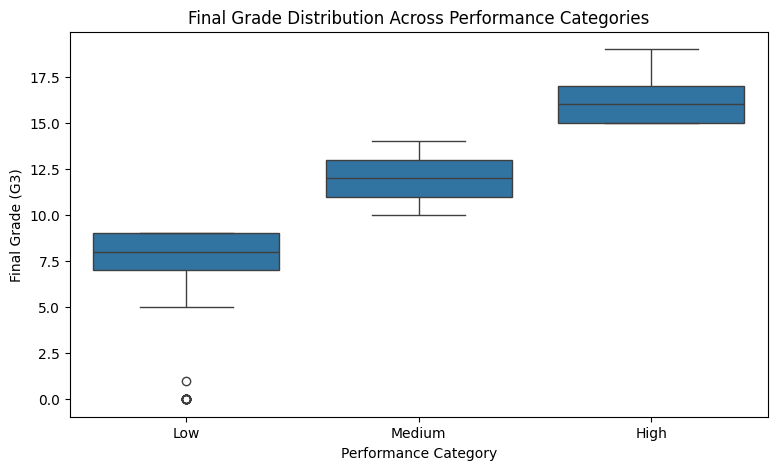

In [33]:
# Compare final grades across performance categories

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="performance_category",
    y="G3",
    order=["Low", "Medium", "High"]
)

plt.title("Final Grade Distribution Across Performance Categories")
plt.xlabel("Performance Category")
plt.ylabel("Final Grade (G3)")

plt.show()

In [34]:
# Calculate correlation between numerical variables

correlation_matrix = df[numerical_columns].corr()

correlation_matrix

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G3
age,1.000000,-0.107832,-0.121050,0.034490,-0.008415,0.319968,-0.020559,-0.004910,0.112805,0.134768,0.086357,-0.008750,0.149998,-0.106505
Medu,-0.107832,1.000000,0.647477,-0.265079,0.097006,-0.172210,0.024421,-0.019686,0.009536,-0.007018,-0.019766,0.004614,-0.008577,0.240151
Fedu,-0.121050,0.647477,1.000000,-0.208288,0.050400,-0.165915,0.020256,0.006841,0.027690,0.000061,0.038445,0.044910,0.029859,0.211800
traveltime,0.034490,-0.265079,-0.208288,1.000000,-0.063154,0.097730,-0.009521,0.000937,0.057454,0.092824,0.057007,-0.048261,-0.008149,-0.127173
studytime,-0.008415,0.097006,0.050400,-0.063154,1.000000,-0.147441,-0.004127,-0.068829,-0.075442,-0.137585,-0.214925,-0.056433,-0.118389,0.249789
failures,0.319968,-0.172210,-0.165915,0.097730,-0.147441,1.000000,-0.062645,0.108995,0.045078,0.105949,0.082266,0.035588,0.122779,-0.393316
famrel,-0.020559,0.024421,0.020256,-0.009521,-0.004127,-0.062645,1.000000,0.129216,0.089707,-0.075767,-0.093511,0.109559,-0.089534,0.063361
freetime,-0.004910,-0.019686,0.006841,0.000937,-0.068829,0.108995,0.129216,1.000000,0.346352,0.109904,0.120244,0.084526,-0.018716,-0.122705
goout,0.112805,0.009536,0.027690,0.057454,-0.075442,0.045078,0.089707,0.346352,1.000000,0.245126,0.388680,-0.015741,0.085374,-0.087641
Dalc,0.134768,-0.007018,0.000061,0.092824,-0.137585,0.105949,-0.075767,0.109904,0.245126,1.000000,0.616561,0.059067,0.172952,-0.204719


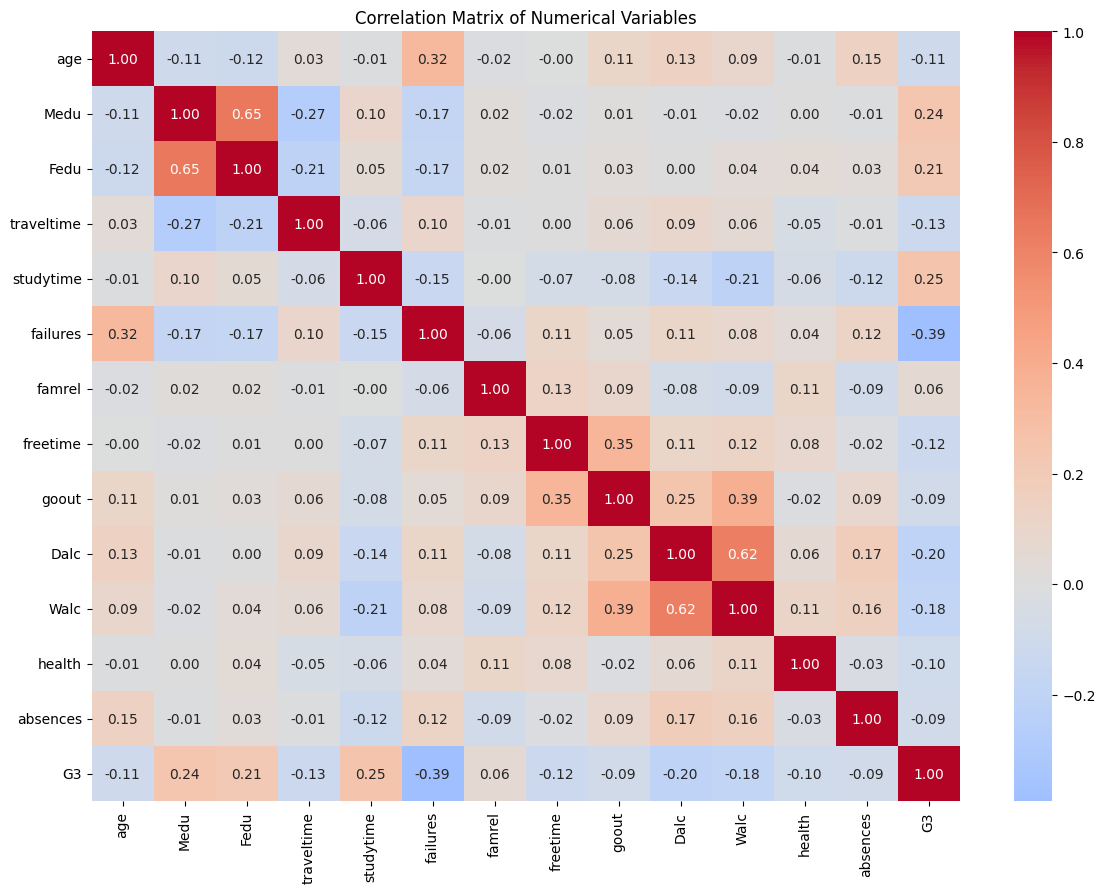

In [35]:
# Visualize correlation matrix

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Variables")

plt.show()

In [36]:
# Create a summary of all features

feature_summary = pd.DataFrame({
    "Feature": df.columns,
    "Data_Type": df.dtypes.astype(str).values,
    "Unique_Values": [
        df[column].nunique()
        for column in df.columns
    ],
    "Missing_Values": [
        df[column].isnull().sum()
        for column in df.columns
    ]
})

feature_summary

,Feature,Data_Type,Unique_Values,Missing_Values
0,school,object,2,0
1,sex,object,2,0
2,age,int64,8,0
3,address,object,2,0
4,famsize,object,2,0
5,Pstatus,object,2,0
6,Medu,int64,5,0
7,Fedu,int64,5,0
8,Mjob,object,5,0
9,Fjob,object,5,0


# Day 03 — Data Understanding Findings

## Dataset Structure

The dataset contains student-related information covering academic,
demographic, family, social and school-related characteristics.

The dataset contains both numerical and categorical features. Some numerical
features are actually coded categories or ordered groups, so their data type
alone should not determine how they are handled during preprocessing.

## Important Features

The following features are particularly relevant to the project:

- `age` — student's age.
- `studytime` — student's weekly study-time category.
- `failures` — number of previous class failures.
- `absences` — number of recorded absences.
- `Medu` — mother's education level.
- `Fedu` — father's education level.
- `schoolsup` — additional educational support from school.
- `famsup` — additional educational support from family.
- `higher` — whether the student wants to pursue higher education.
- `internet` — availability of internet access at home.
- `G3` — final student grade.

## Performance Categories

For this project, the final grade (`G3`) was converted into three performance
categories:

- `Low` — G3 below 10
- `Medium` — G3 from 10 to below 15
- `High` — G3 from 15 to 20

These categories are project-defined labels used for the classification task.

## Observations From Analysis

The dataset shows differences in student characteristics across the
performance categories. Study time, previous failures and absences were
examined to understand how they are distributed across different performance
groups.

The visual analysis is used to identify patterns and associations in the
dataset. These observations should not be treated as proof that a particular
feature directly causes higher or lower academic performance.

## Academic Grade Information

The currently loaded dataset contains the final grade `G3`. The variables
`G1` and `G2` are not present in this version of the dataset.

Therefore, the project will use `G3` as the target variable and will focus on
the other available student characteristics as input features.

## Preprocessing Considerations

The analysis shows that the dataset contains a mixture of numerical and
categorical variables. Before machine learning, categorical variables will
need appropriate encoding.

Some numerical variables represent ordered categories or coded responses.
These variables will therefore require careful consideration during feature
preparation.

The dataset structure, feature types and distributions identified during
Day 03 will be used to guide the data-cleaning and preprocessing stages.

## Conclusion

Day 03 provided a detailed understanding of the dataset before machine
learning development. The next stage will focus on checking data quality,
including missing values, duplicate records, inconsistent values and other
issues that may affect model development.

# DAY 03 DEVELOPMENT LOG

## Work Completed

- Created an independent Day 03 notebook.
- Loaded the selected Student Performance dataset.
- Reconstructed the working DataFrame.
- Created the project performance categories.
- Inspected the dataset dimensions.
- Listed all available features.
- Examined feature data types.
- Identified numerical and categorical variables.
- Generated statistical summaries.
- Examined the number of unique values in each feature.
- Inspected categorical feature values.
- Analyzed the final grade (`G3`).
- Analyzed student study time.
- Analyzed previous failures.
- Analyzed student absences.
- Examined age distribution.
- Examined gender distribution.
- Compared performance categories with study time.
- Compared performance categories with previous failures.
- Compared absences across performance categories.
- Analyzed the distribution of final grades.
- Compared final grades across performance categories.
- Generated a correlation matrix for numerical variables.
- Created a complete feature summary.
- Confirmed that `G1` and `G2` are not available in the currently loaded dataset.

## Key Learning

Understanding the dataset before machine learning is important because it
helps determine which features need encoding, transformation or other
preprocessing.

The analysis also showed that some numerical values represent categories or
ordered responses. Therefore, feature meaning must be considered instead of
relying only on the stored data type.

## Important Project Decision

The current dataset contains `G3` as the final grade but does not contain
`G1` or `G2`. Therefore, `G3` will be used as the target variable and the
available student characteristics will be used as input features.

## Next Step

Day 04 will focus on data quality analysis, including missing values,
duplicate records, inconsistent values and features that may require special
preprocessing before machine learning.